In [1]:
import pandas as pd
import sqlite3

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics

# LOAD

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# TODO: Cambiar para que apunte al directorio correcto
DIR = "/content/drive/MyDrive/UBA/Especializacion/DM/Data"

Leo los datos de entrenamiento

In [4]:
# Path a la BD
DIR = "/content/drive/MyDrive/UBA/Especializacion/DM/Data"

engine = sqlite3.connect(f"{DIR}/entrenamiento.db")

# Leo los datos de entranmiento
df_ent = pd.read_sql("SELECT * FROM entrenamiento", engine, index_col="id")
df_ent.head(3)

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,location_3,location_4,operation_type,property_type,source,price,currency_type
id,,,,,,,,,,,,,,,,,
0,galpón de 275 metros cuadrados cubiertos. ...,"Soldini, Rosario, Santa Fe, ARG",-33.008797,-60.743675,"Hace 1 semana, 17 horas",None,electricidad;cerca de:,Argentina,Santa Fe,Soldini,Rosario,None,venta,galpón,properati,150000.0,dolares
1,"venta de galpón en barrio urquiza, rosario sob...","Boulevard 27 de Febrero, Rosario, S2009, Santa...",-32.959099,-60.710079,1 ene 2026,None,1 baño;700 m²;electricidad;cerca de:,Argentina,Santa Fe,Rosario,Rosario,None,venta,galpón,properati,250000.0,dolares
2,mira esta y otras propiedades en nuestro sitio...,"Calle Virasoro 3450, Rosario, S2003, Santa Fe,...",-32.963959,-60.675930,30 nov 2025,None,2 dormitorios;1 baño;250 m²;internet;electrici...,Argentina,Santa Fe,Rosario,Rosario,None,venta,galpón,properati,130000.0,dolares


Leo los datos a predecir

In [5]:
df_ap = pd.read_csv(f"{DIR}/a_predecir.csv", index_col="id")
df_ap.head(2)

,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,location_3,location_4,operation_type,property_type,source,price,currency_type
id,,,,,,,,,,,,,,,,,
264893,casa construida en 2 plantas. capacidad para ...,"Calle Esmeralda 599, Buenos Aires, Ciudad Autó...",-34.601357,-58.378109,3 nov 2024,NaN,4 dormitorios;4 baños;308 m²;internet;balcón;c...,Argentina,Ciudad Autónoma de Buenos Aires,Buenos Aires,Ciudad Autónoma de Buenos Aires,NaN,venta,casa,properati,NaN,dolares
264899,congreso piso 4 ambientes antiguo reciclado mu...,"República Bolivariana de Venezuela 1699, Monts...",-34.614742,-58.390285,18 nov 2022,NaN,3 dormitorios;3 baños;91 m²;balcón;gas natural...,Argentina,Ciudad Autónoma de Buenos Aires,Montserrat,Ciudad de Buenos Aires,NaN,venta,casa,properati,NaN,dolares


# A. Analisis exploratorio


## 1.Exploración del conjunto de datos

Dataset a PREDECIR.

Estructura:

*   Columanas =  17
*   Filas = 13471

Campos con valores nulos:

*   address
*   lat
*   lon
*   publication_date
*   publisher_id  
*   location_4

Campos númericos:

*   lat
*   lon
*   publisher_id
*   price

In [6]:
df_ap.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13471 entries, 264893 to 696882
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   description       13471 non-null  object 
 1   address           13426 non-null  object 
 2   lat               3524 non-null   float64
 3   lon               3524 non-null   float64
 4   publication_date  3524 non-null   object 
 5   publisher_id      10007 non-null  float64
 6   features          13471 non-null  object 
 7   location_0        13471 non-null  object 
 8   location_1        13471 non-null  object 
 9   location_2        13471 non-null  object 
 10  location_3        13417 non-null  object 
 11  location_4        698 non-null    object 
 12  operation_type    13471 non-null  object 
 13  property_type     13471 non-null  object 
 14  source            13411 non-null  object 
 15  price             0 non-null      float64
 16  currency_type     13471 non-null  objec

### Valores únicos

Comparación de la información que contiene cada ATRIBUTOS entre el dataset de **entrenamiento** y **a predecir**

#### Operación

In [7]:
# Dataset: Tipo de operaciones
print(f"Dataset a predecir - Operaciones:\n-{df_ap.operation_type.unique()}\n")
print(f"Dataset a entrenar - Operaciones:\n-{df_ent.operation_type.unique()}")

Dataset a predecir - Operaciones:
-['venta']

Dataset a entrenar - Operaciones:
-['venta' None 'alquiler' 'temporal' 'alquiler / temporal'
 'venta / temporal' 'venta / alquiler' 'venta / alquiler / temporal'
 'traspaso' 'renta' 'alquiler temporal' 'sin operacion']


#### Tipo de propiedad

In [8]:
print(f"Dataset a predecir - Propiedad:\n-{df_ap.property_type.unique()}\n")
print(f"Dataset a entrenar - Propiedad:\n-{df_ent.property_type.unique()}")

Dataset a predecir - Propiedad:
-['casa' 'departamento' 'cochera']

Dataset a entrenar - Propiedad:
-['galpón' None 'casa' 'terreno' 'departamento' 'local comercial' 'oficina'
 'cochera' 'villa' 'terrenos' 'garage' 'oficina comercial' 'ph'
 'consultorio' 'bodega-galpón' 'hotel' 'edificio' 'depósito' 'campo'
 'quinta vacacional' 'fondo de comercio' 'desarrollo vertical'
 'desarrollo horizontal' 'bóveda, nicho o parcela' 'cama náutica'
 'casa-duplex' 'galpon' 'quinta' 'cabana' 'penthouse' 'loft'
 'fondo-de-comercio' 'inmueble-productivo' 'local' 'fabrica' 'nave'
 'deposito' 'oficinas' 'departamentos' 'casas' 'comercios' 'depósitos'
 'emprendimientos' 'plantas industriales' 'cocheras' 'hoteles'
 'negocioespecial' 'fondocomercio' 'emprendimiento']


#### Geolocalización
Se encuentra diferencia entre país, provincia y ciudad

In [9]:
print(f"Dataset a predecir - País:\n-{df_ap.location_0.unique()}\n")
print(f"Dataset a entrenar - País:\n-{df_ent.location_0.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Provincia:\n-{df_ap.location_1.unique()}\n")
print(f"Dataset a entrenar - Provincia:\n-{df_ent.location_1.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Ciudad:\n-{df_ap.location_2.unique()}\n")
print(f"Dataset a entrenar - Ciudad:\n-{df_ent.location_2.unique()}")


# print("Barrio:")
# print(df_ap.location_3.unique())
# print("subbarrio")
# print(df_ap.location_4.unique())

Dataset a predecir - País:
-['Argentina']

Dataset a entrenar - País:
-['Argentina' None 'Uruguay' 'España' 'Estados Unidos' 'Paraguay'
 'Otros países' 'Chile' 'Emiratos Arabes Unidos' 'Brasil' 'Peru']

------------------------------------------------------------------------------------------
Dataset a predecir - Provincia:
-['Ciudad Autónoma de Buenos Aires' 'Capital Federal']

Dataset a entrenar - Provincia:
-['Santa Fe' 'Provincia de Buenos Aires' 'Ciudad Autónoma de Buenos Aires'
 'Entre Ríos' 'Córdoba' 'Salta' 'Tucumán' 'San Juan' 'Chubut' 'Santa Cruz'
 'Mendoza' 'Buenos Aires' 'National Capital Region' 'Misiones'
 'Distrito Capital' 'San Luis' 'Chaco' 'Río Negro' 'Neuquén' 'La Pampa'
 'Tierra del Fuego Antártida e Islas del Atlántico Sur' None
 'Santiago del Estero' 'Corrientes' 'Jujuy' 'Catamarca' 'San Salvador'
 'Región Metropolitana de Santiago' 'Bíobío' 'Biobío' 'La Rioja' 'Olancho'
 "Libertador Gral. Bernardo O'Higgins" 'Coquimbo' 'Los Lagos' 'Valparaíso'
 'Tierra del Fuego'

#### Moneda

In [10]:
print(f"Dataset a predecir - Moneda:\n-{df_ap.currency_type.unique()}\n")
print(f"Dataset a entrenar - Moneda:\n-{df_ent.currency_type.unique()}\n")

Dataset a predecir - Moneda:
-['dolares' 'pesos']

Dataset a entrenar - Moneda:
-['dolares' 'Otro' 'pesos']



#### Fuente de información

In [11]:
print(f"Dataset a predecir - Fuente de datos:\n-{df_ap.source.unique()}\n")
print(f"Dataset a entrenar - Fuente de datos:\n-{df_ent.source.unique()}\n")

Dataset a predecir - Fuente de datos:
-['properati' nan 'argenprop']

Dataset a entrenar - Fuente de datos:
-['properati' 'zonaprop' None 'mudafy' 'argenprop']



# B. Representaciones gráficas y análisis.

In [12]:
import matplotlib.pyplot as plt

### 1.Ciudad según tipo de propiedad

In [13]:
df_ap.groupby("property_type")[["location_0","location_1","location_2"]].count().reset_index()

,property_type,location_0,location_1,location_2
0,casa,2633,2633,2633
1,cochera,21,21,21
2,departamento,10817,10817,10817


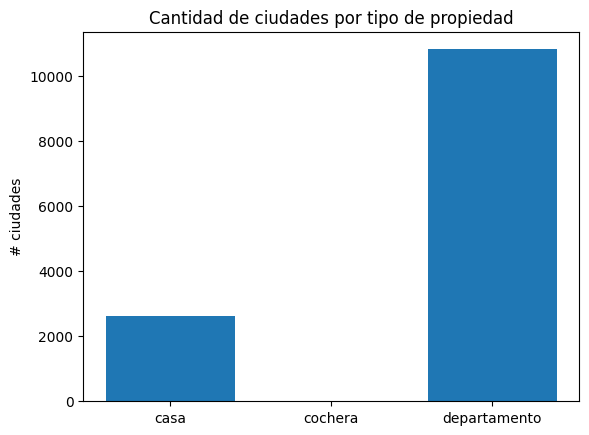

In [14]:
data = df_ap.groupby("property_type")[["location_0","location_1","location_2"]].count().reset_index()
fig, ax = plt.subplots()
ax.bar(data.property_type, data.location_1)
ax.set_ylabel('# ciudades')
ax.set_title('Cantidad de ciudades por tipo de propiedad')
# ax.legend(title='Fruit color')

plt.show()

<Axes: >

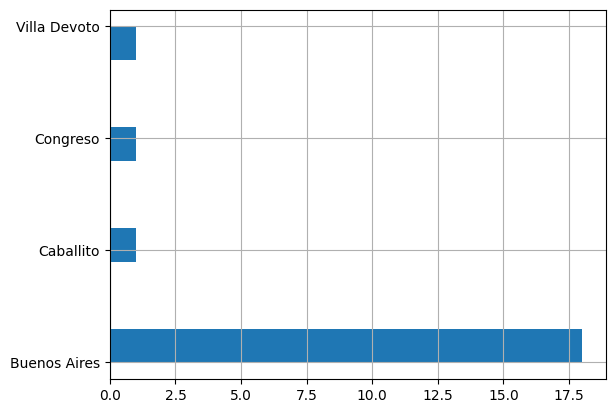

In [15]:
df_ap.loc[df_ap["property_type"] == "cochera", "location_2"].hist(orientation="horizontal")

<Axes: >

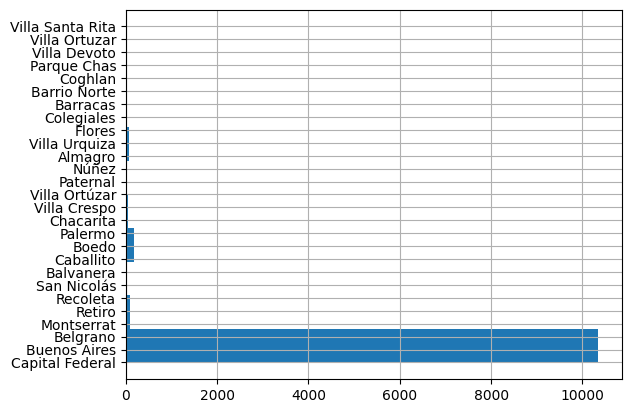

In [16]:
df_ap.loc[df_ap["property_type"] == "departamento", "location_2"].hist(orientation="horizontal")

<Axes: >

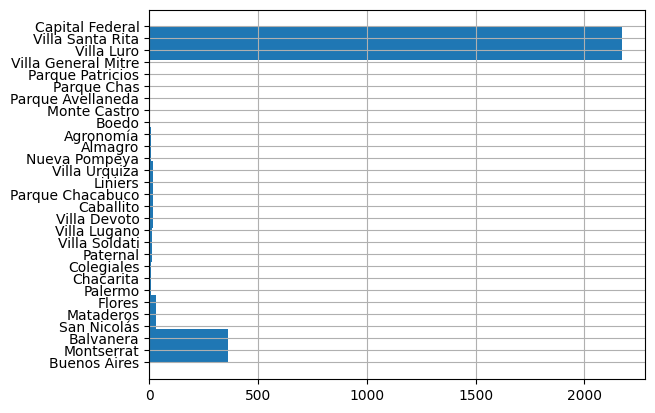

In [17]:
df_ap.loc[df_ap["property_type"] == "casa", "location_2"].hist(orientation="horizontal")

### 2.Precio según tipo de propiedad

Dataset de ENTRENAMIIENTO
Filtrando solo propiedades que pertenecen al dataset "a predecir".

In [18]:
data.describe()

,location_0,location_1,location_2
count,3.000000,3.000000,3.000000
mean,4490.333333,4490.333333,4490.333333
std,5632.554423,5632.554423,5632.554423
min,21.000000,21.000000,21.000000
25%,1327.000000,1327.000000,1327.000000
50%,2633.000000,2633.000000,2633.000000
75%,6725.000000,6725.000000,6725.000000
max,10817.000000,10817.000000,10817.000000


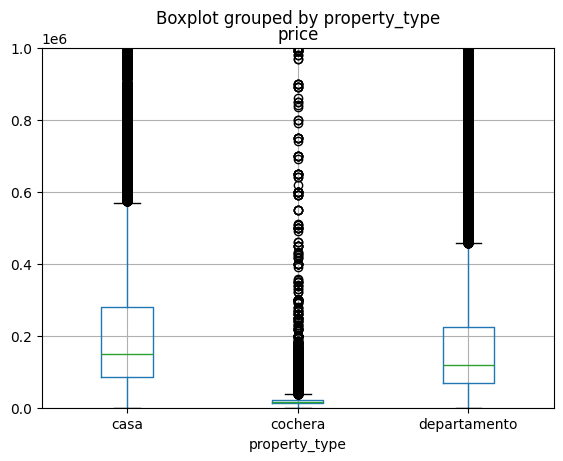

In [19]:
data = df_ent.loc[df_ent["property_type"].isin(["casa","cochera","departamento"])]

fig, ax = plt.subplots()
data.boxplot(by="property_type", column="price", ax=ax)
ax.set_ylim([0,10**6])
plt.show()

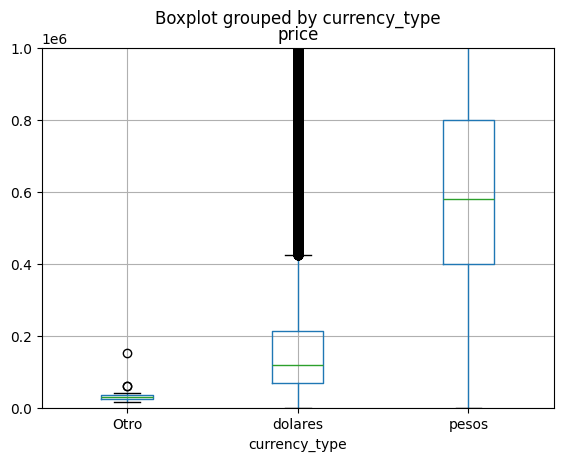

In [20]:
# Moneda
fig, ax = plt.subplots()
data.boxplot(by="currency_type", column="price", ax=ax)
ax.set_ylim([0,10**6])
plt.show()

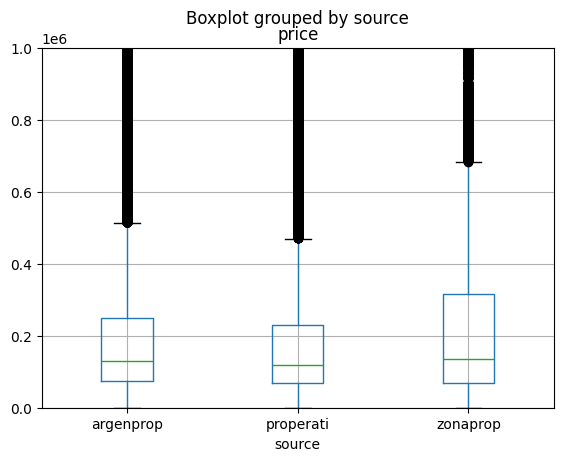

In [21]:
# Source
fig, ax = plt.subplots()
data.boxplot(by="source", column="price", ax=ax)
ax.set_ylim([0,10**6])
plt.show()

# C. Medidas de posición

### 1.media,mediana.moda

In [28]:
data.groupby(["property_type"])["price"].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
casa,247969.0,3.770422e+05,1.017224e+07,1.0,85000.0,150000.0,279000.0,1.500000e+09
cochera,15161.0,4.751482e+04,4.437690e+05,15.0,12000.0,16000.0,22000.0,3.000000e+07
departamento,367034.0,3.334916e+08,1.843168e+11,1.0,70000.0,118500.0,225000.0,1.111111e+14


### 2.Gráfico de torta

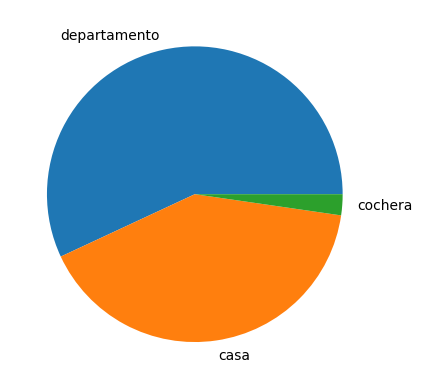

In [52]:
labels = data.property_type.value_counts().index
data_pie = data.property_type.value_counts().values

fig, ax = plt.subplots()
ax.pie(data_pie, labels=labels)
plt.show()